In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import rankdata, norm
import warnings
warnings.filterwarnings('ignore')

import gstools as gs

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

url = "/home/wasif/sds/data/2D_MV_200Wells.csv"

mydata = pd.read_csv(url)

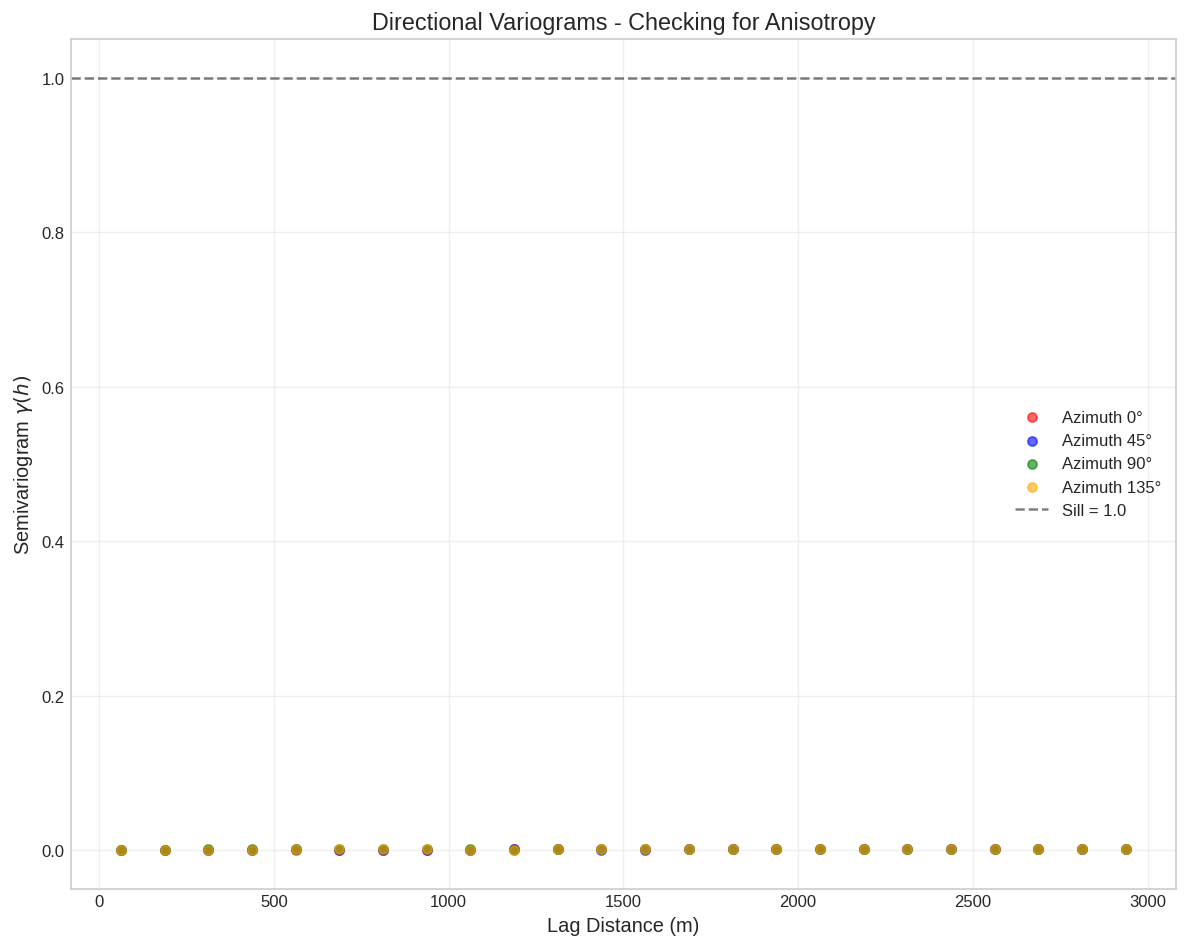

Observing the directional variograms can reveal anisotropy.
If ranges differ by direction, the phenomenon is geometrically anisotropic.


In [5]:
import gstools as gs
import numpy as np

coords = mydata[['X', 'Y']].values.T  # Shape: (2, 200)
values = mydata['porosity'].values

# Define bin edges
max_dist = 3000
n_bins = 24
bin_edges = np.linspace(0, max_dist, n_bins + 1)

# Compute directional variograms at different azimuths (in radians)
# Convert azimuth angles from degrees to radians
azimuths_deg = [0, 45, 90, 135]
azimuths_rad = np.deg2rad(azimuths_deg)  # Convert to radians for gstools
colors = ['red', 'blue', 'green', 'orange']
bandwidth_deg = 22.5
angles_tol_rad = np.deg2rad(bandwidth_deg)  # Convert tolerance to radians

fig, ax = plt.subplots(figsize=(10, 8))

# For each azimuth, compute directional variogram using 'angles' parameter
for az_rad, az_deg, color in zip(azimuths_rad, azimuths_deg, colors):
    # Use 'angles' parameter with radians (counter-clockwise from +x axis)
    lags_dir, gamma_dir = gs.vario_estimate(
        coords,              # transposed coordinates (2, n_points)
        values,
        bin_edges=bin_edges,
        angles=az_rad,       # azimuth in radians (CCW from +x)
        angles_tol=angles_tol_rad,  # tolerance in radians
        return_counts=False
    )
    
    # Plot
    ax.scatter(lags_dir, gamma_dir, c=color, s=30, alpha=0.6, label=f'Azimuth {az_deg}°')

# Add reference line
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Sill = 1.0')

ax.set_xlabel('Lag Distance (m)', fontsize=12)
ax.set_ylabel('Semivariogram $\gamma(h)$', fontsize=12)
ax.set_title('Directional Variograms - Checking for Anisotropy', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('directional_variograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observing the directional variograms can reveal anisotropy.")
print("If ranges differ by direction, the phenomenon is geometrically anisotropic.")

In [7]:
azimuths_deg = [0, 45, 90, 135]

for az_rad, az_deg, color in zip(np.radians(azimuths_deg), azimuths_deg, ['red', 'blue', 'green', 'orange']):
    lags_dir, gamma_dir = gs.vario_estimate(
        coords, values,
        bin_edges=bin_edges,
        angles=az_rad,
        angles_tol=angles_tol_rad
    )
    print(f"Azimuth {az_deg}°: Lag distances (first 5) = {lags_dir[:5]}, Gamma values (first 5) = {gamma_dir[:5]}")

Azimuth 0°: Lag distances (first 5) = [ 62.5 187.5 312.5 437.5 562.5], Gamma values (first 5) = [0.00050932 0.00055118 0.00082102 0.00082062 0.00076389]
Azimuth 45°: Lag distances (first 5) = [ 62.5 187.5 312.5 437.5 562.5], Gamma values (first 5) = [0.00032537 0.00044335 0.00066104 0.00078944 0.00090459]
Azimuth 90°: Lag distances (first 5) = [ 62.5 187.5 312.5 437.5 562.5], Gamma values (first 5) = [0.00048849 0.00048388 0.00088648 0.0009413  0.00097131]
Azimuth 135°: Lag distances (first 5) = [ 62.5 187.5 312.5 437.5 562.5], Gamma values (first 5) = [0.00043806 0.00077747 0.00058686 0.0006367  0.00113376]


In [8]:
model = gs.Spherical(dim=2, var=sill_fit, len_scale=range_fit, nugget=nugget_fit)
print(f"Fitted spherical model parameters:")
print(f"  Nugget: {model.nugget:.3f}")
print(f"  Sill: {model.var:.3f}")
print(f"  Range: {model.len_scale:.1f} m")

model.fit_variogram(lags, gamma)
print(f"Fitted variogram model parameters:")
print(f"  Nugget: {model.nugget:.3f}")
print(f"  Sill: {model.var:.3f}")
print(f"  Range: {model.len_scale:.1f} m")


NameError: name 'sill_fit' is not defined

nugget: 0.5177
sill:   0.6515
range:  3354.3 m

   Direction      Nugget        Sill    Total Sill     Range (m)
--------------------------------------------------------------
         0°      0.6571      0.3429        1.0000        3976.1
        45°      0.5568      0.4432        1.0000        2693.6
        90°      0.5396      0.4604        1.0000        2189.1
       135°      0.5192      0.4808        1.0000        1839.2


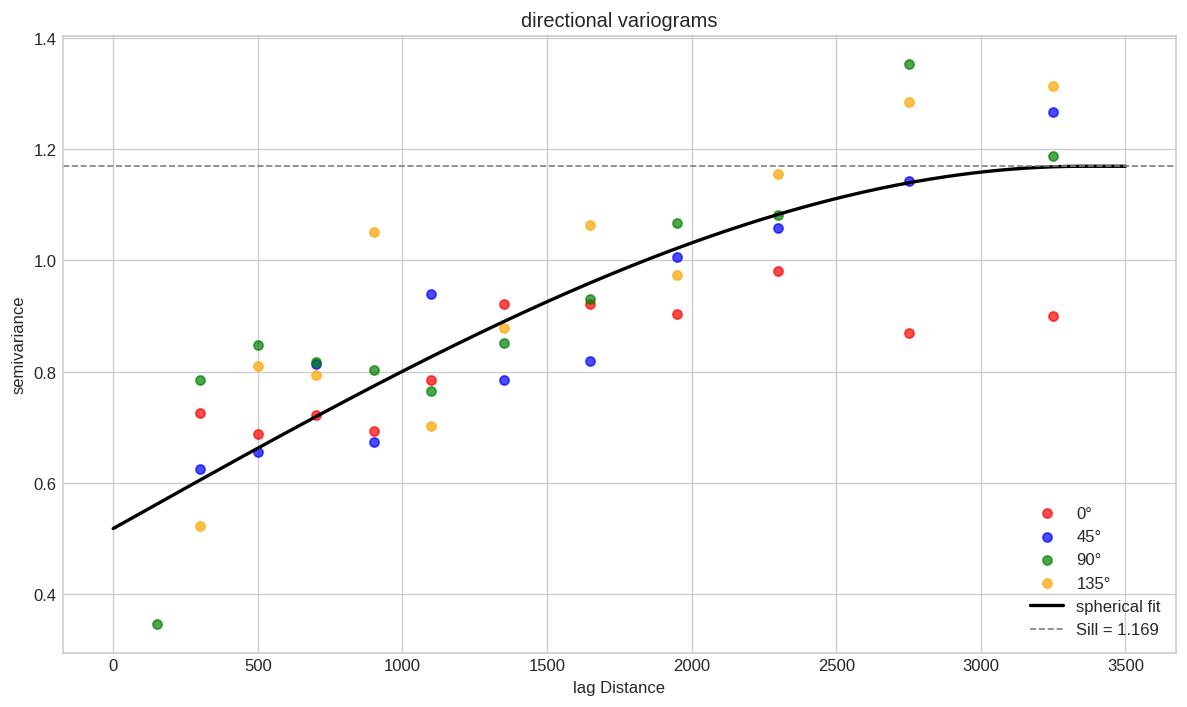

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gstools as gs
from scipy.stats import rankdata, norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

url = "/home/wasif/sds/data/2D_MV_200Wells.csv"
mydata = pd.read_csv(url)

coords = mydata[['X', 'Y']].values.T
raw    = mydata['porosity'].values

ranks  = rankdata(raw, method='average')
p      = (ranks - 3/8) / (len(raw) + 1/4)
values = norm.ppf(p)

max_dist  = 3500
bin_edges = np.array([0, 100, 200, 400, 600, 800, 1000,
                      1200, 1500, 1800, 2100, 2500, 3000, 3500], dtype=float)

lags, gamma, counts = gs.vario_estimate(
    coords, values,
    bin_edges=bin_edges,
    return_counts=True,
    direction=None
)

mask  = counts >= 30
lags  = lags[mask]
gamma = gamma[mask]

model = gs.Spherical(dim=2)
model.fit_variogram(lags, gamma)

nugget_fit = model.nugget
sill_fit   = model.var
range_fit  = model.len_scale

print(f"nugget: {nugget_fit:.4f}")
print(f"sill:   {sill_fit:.4f}")
print(f"range:  {range_fit:.1f} m")

azimuths_deg   = [0, 45, 90, 135]
colors         = ['red', 'blue', 'green', 'orange']
angles_tol_rad = np.deg2rad(22.5)

print(f"\n{'Direction':>12}  {'Nugget':>10}  {'Sill':>10}  {'Total Sill':>12}  {'Range (m)':>12}")
print("-" * 62)

fig, ax = plt.subplots(figsize=(10, 6))

for az_deg, color in zip(azimuths_deg, colors):
    az_rad = np.deg2rad(az_deg)
    lags_dir, gamma_dir, cnt = gs.vario_estimate(
        coords, values,
        bin_edges=bin_edges,
        angles=az_rad,
        angles_tol=angles_tol_rad,
        return_counts=True
    )
    m = cnt >= 30

    m_model = gs.Spherical(dim=2)
    m_model.fit_variogram(lags_dir[m], gamma_dir[m], sill=1.0)

    print(f"{az_deg:>10}°  {m_model.nugget:>10.4f}  {m_model.var:>10.4f}  {m_model.nugget + m_model.var:>12.4f}  {m_model.len_scale:>12.1f}")

    ax.scatter(lags_dir[m], gamma_dir[m], c=color, s=30, alpha=0.7, label=f'{az_deg}°')

lags_plot = np.linspace(0, max_dist, 300)
ax.plot(lags_plot, model.variogram(lags_plot), 'k-', lw=2, label='spherical fit')
ax.axhline(nugget_fit + sill_fit, color='gray', linestyle='--', lw=1, label=f'Sill = {nugget_fit + sill_fit:.3f}')

ax.set_xlabel('lag Distance')
ax.set_ylabel('semivariance')
ax.set_title('directional variograms')
ax.legend()
plt.tight_layout()
plt.show()

0.001085565257786432
nugget: 0.0005
sill:   0.0006
range:  1477.5 m

   Direction      Nugget        Sill    Total Sill     Range (m)
--------------------------------------------------------------
         0°      0.0007      0.0003        0.0010        2539.1
        45°      0.0006      0.0051        0.0058       33345.9
        90°      0.0006      0.0011        0.0017        6129.3
       135°      0.0006      0.0013        0.0020        7081.6


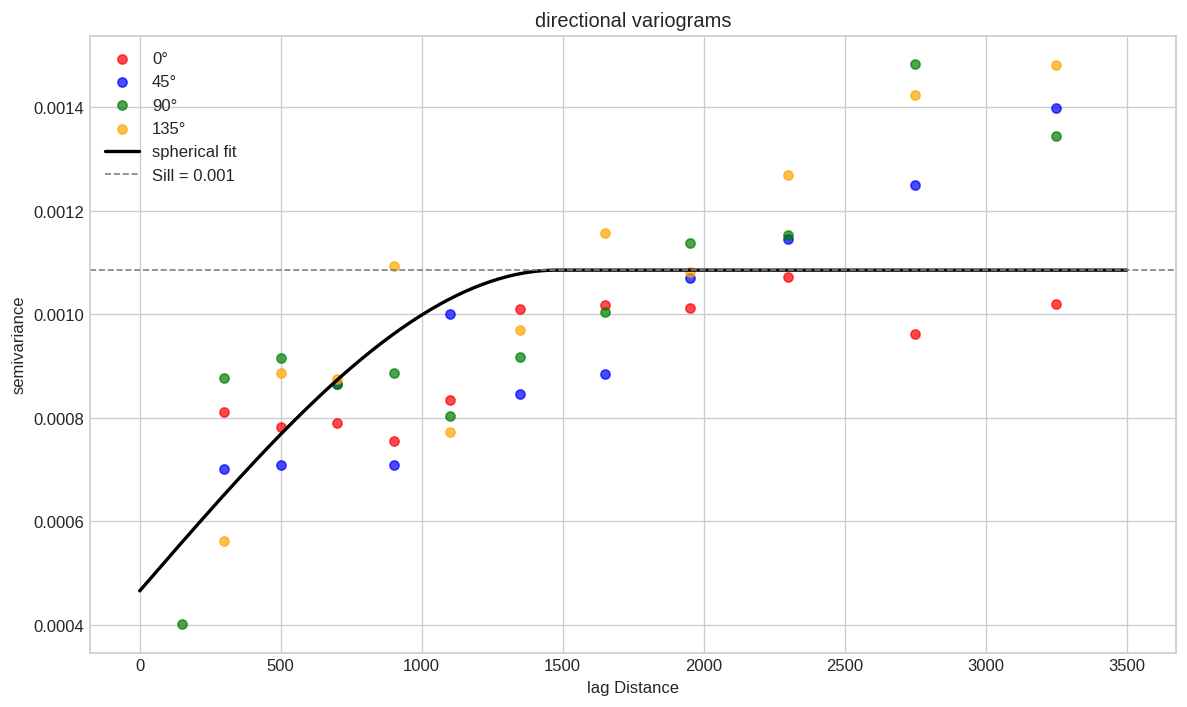

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gstools as gs
from scipy.stats import rankdata, norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

url = "/home/wasif/sds/data/2D_MV_200Wells.csv"
mydata = pd.read_csv(url)

coords = mydata[['X', 'Y']].values.T
raw    = mydata['porosity'].values

ranks  = rankdata(raw, method='average')
p      = (ranks - 3/8) / (len(raw) + 1/4)
values = raw.copy()


max_dist  = 3500
bin_edges = np.array([0, 100, 200, 400, 600, 800, 1000,
                      1200, 1500, 1800, 2100, 2500, 3000, 3500], dtype=float)

lags, gamma, counts = gs.vario_estimate(
    coords, values,
    bin_edges=bin_edges,
    return_counts=True,
    direction=None
)

mask  = counts >= 30
lags  = lags[mask]
gamma = gamma[mask]

data_var = np.var(values, ddof=1)
print(data_var)
model = gs.Spherical(dim=2)
model.fit_variogram(lags, gamma, sill= data_var)

nugget_fit = model.nugget
sill_fit   = model.var
range_fit  = model.len_scale

print(f"nugget: {nugget_fit:.4f}")
print(f"sill:   {sill_fit:.4f}")
print(f"range:  {range_fit:.1f} m")

azimuths_deg   = [0, 45, 90, 135]
colors         = ['red', 'blue', 'green', 'orange']
angles_tol_rad = np.deg2rad(22.5)

print(f"\n{'Direction':>12}  {'Nugget':>10}  {'Sill':>10}  {'Total Sill':>12}  {'Range (m)':>12}")
print("-" * 62)

fig, ax = plt.subplots(figsize=(10, 6))

for az_deg, color in zip(azimuths_deg, colors):
    az_rad = np.deg2rad(az_deg)
    lags_dir, gamma_dir, cnt = gs.vario_estimate(
        coords, values,
        bin_edges=bin_edges,
        angles=az_rad,
        angles_tol=angles_tol_rad,
        return_counts=True
    )
    m = cnt >= 30

    m_model = gs.Spherical(dim=2)
    m_model.fit_variogram(lags_dir[m], gamma_dir[m],nugget=True)

    print(f"{az_deg:>10}°  {m_model.nugget:>10.4f}  {m_model.var:>10.4f}  {m_model.nugget + m_model.var:>12.4f}  {m_model.len_scale:>12.1f}")

    ax.scatter(lags_dir[m], gamma_dir[m], c=color, s=30, alpha=0.7, label=f'{az_deg}°')

lags_plot = np.linspace(0, max_dist, 300)
ax.plot(lags_plot, model.variogram(lags_plot), 'k-', lw=2, label='spherical fit')
ax.axhline(nugget_fit + sill_fit, color='gray', linestyle='--', lw=1, label=f'Sill = {nugget_fit + sill_fit:.3f}')

ax.set_xlabel('lag Distance')
ax.set_ylabel('semivariance')
ax.set_title('directional variograms')
ax.legend()
plt.tight_layout()
plt.show()